# HW08-09

Цель: освоить PyTorch и обучить нейронную сеть на датасете EMNIST используя лучшие инженерные практики.

## Датасет
Выбран датасет EMNIST(split="balanced").

Входные изображения имеют размер 1x28x28, поэтому MLP получает 784 признака после расплатсовки.

Число классов в датасете - 47, поэтому последний слой модели выдает 47 logits.

In [1]:
from pathlib import Path
from copy import deepcopy
import os
import json
import math
import time
import random
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import datasets, transforms

In [2]:
SEED = 42
DATASET_NAME = "EMNIST_BALANCED"   # "KMNIST" | "EMNIST_BALANCED" | "CIFAR10"
VAL_RATIO = 0.2

BATCH_SIZE = 256 if torch.cuda.is_available() else 128
NUM_WORKERS = 0

MAX_EPOCHS_A = 20 if torch.cuda.is_available() else 15   # E1-E3
MAX_EPOCHS_E4 = 40 if torch.cuda.is_available() else 25  # E4 с EarlyStopping
EPOCHS_LR_EXTREMES = 6                                   # O1-O2
EPOCHS_O3 = 12 if torch.cuda.is_available() else 10      # O3

EARLY_STOPPING_PATIENCE = 4
EARLY_STOPPING_MIN_DELTA = 1e-4

HW_DIR = Path()
ARTIFACTS_DIR = HW_DIR / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"

for path in [HW_DIR, ARTIFACTS_DIR, FIGURES_DIR]:
	path.mkdir(parents=True, exist_ok=True)

RUNS_CSV_PATH = ARTIFACTS_DIR / "runs.csv"
BEST_MODEL_PATH = ARTIFACTS_DIR / "best_model.pt"
BEST_CONFIG_PATH = ARTIFACTS_DIR / "best_config.json"
CURVES_BEST_PATH = FIGURES_DIR / "curves_best.png"
CURVES_LR_EXTREMES_PATH = FIGURES_DIR / "curves_lr_extremes.png"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("DEVICE:", DEVICE)
print("HW_DIR:", HW_DIR.resolve())

DEVICE: cuda
HW_DIR: /root/source/awesome-ai-engineer/homeworks/HW08-09


In [3]:
def set_seed(seed: int = 42) -> None:
	random.seed(seed)
	np.random.seed(seed)
	torch.manual_seed(seed)
	torch.cuda.manual_seed_all(seed)

	torch.backends.cudnn.deterministic = True
	torch.backends.cudnn.benchmark = False


set_seed(SEED)

print("Python:", platform.python_version())
print("torch:", torch.__version__)
print("torchvision:", getattr(torchvision, "__version__", "unknown"))
print("device:", DEVICE)
print("seed:", SEED)

Python: 3.13.5
torch: 2.10.0+cu128
torchvision: 0.25.0+cu128
device: cuda
seed: 42


In [4]:
# build_transform for EMNIST (balanced)
def build_transform():
	transform = transforms.Compose([
		transforms.ToTensor(),
		transforms.Normalize((0.5,), (0.5,))
	])
	transform_desc = "ToTensor() + Normalize((0.5,), (0.5,))"
	return transform, transform_desc


def load_dataset():
	transform, transform_desc = build_transform()

	ds_train_full = datasets.EMNIST(root="./data", split="balanced", train=True, download=True, transform=transform)
	ds_test = datasets.EMNIST(root="./data", split="balanced", train=False, download=True, transform=transform)
	input_shape = (1, 28, 28)
	class_names = getattr(ds_train_full, "classes", None)
	if class_names is None:
		class_names = [str(i) for i in range(47)]
	num_classes = len(class_names)
	dataset_note = "EMNIST Balanced: 47 классов, grayscale, 28x28."

	return {
		"train_full": ds_train_full,
		"test": ds_test,
		"input_shape": input_shape,
		"num_classes": num_classes,
		"class_names": class_names,
		"transform_desc": transform_desc,
		"dataset_note": dataset_note,
	}


bundle = load_dataset()

ds_train_full = bundle["train_full"]
ds_test = bundle["test"]
INPUT_SHAPE = bundle["input_shape"]
NUM_CLASSES = bundle["num_classes"]
CLASS_NAMES = bundle["class_names"]
TRANSFORM_DESC = bundle["transform_desc"]
DATASET_NOTE = bundle["dataset_note"]

print("DATASET:", DATASET_NAME)
print("train_full:", len(ds_train_full))
print("test:", len(ds_test))
print("input_shape:", INPUT_SHAPE)
print("num_classes:", NUM_CLASSES)
print("transform:", TRANSFORM_DESC)
print("note:", DATASET_NOTE)

100.0%


DATASET: EMNIST_BALANCED
train_full: 112800
test: 18800
input_shape: (1, 28, 28)
num_classes: 47
transform: ToTensor() + Normalize((0.5,), (0.5,))
note: EMNIST Balanced: 47 классов, grayscale, 28x28.


In [5]:
def make_loaders(
	ds_train_full,
	ds_test,
	val_ratio: float = 0.2,
	seed: int = 42,
	batch_size: int = 128,
	num_workers: int = 0,
):
	n_total = len(ds_train_full)
	n_val = int(n_total * val_ratio)
	n_train = n_total - n_val

	generator = torch.Generator().manual_seed(seed)
	ds_train, ds_val = random_split(ds_train_full, [n_train, n_val], generator=generator)

	train_loader = DataLoader(
		ds_train,
		batch_size=batch_size,
		shuffle=True,
		num_workers=num_workers,
		pin_memory=torch.cuda.is_available(),
	)
	val_loader = DataLoader(
		ds_val,
		batch_size=batch_size,
		shuffle=False,
		num_workers=num_workers,
		pin_memory=torch.cuda.is_available(),
	)
	test_loader = DataLoader(
		ds_test,
		batch_size=batch_size,
		shuffle=False,
		num_workers=num_workers,
		pin_memory=torch.cuda.is_available(),
	)
	return ds_train, ds_val, train_loader, val_loader, test_loader


ds_train, ds_val, train_loader, val_loader, test_loader = make_loaders(
	ds_train_full,
	ds_test,
	val_ratio=VAL_RATIO,
	seed=SEED,
	batch_size=BATCH_SIZE,
	num_workers=NUM_WORKERS,
)

x_batch, y_batch = next(iter(train_loader))

print("train size:", len(ds_train))
print("val size:", len(ds_val))
print("test size:", len(ds_test))
print("x_batch.shape:", x_batch.shape)
print("y_batch.shape:", y_batch.shape)
print("x_batch dtype:", x_batch.dtype)
print("y_batch dtype:", y_batch.dtype)
print("x range:", float(x_batch.min()), float(x_batch.max()))
print("y unique (first batch):", torch.unique(y_batch).tolist())

train size: 90240
val size: 22560
test size: 18800
x_batch.shape: torch.Size([256, 1, 28, 28])
y_batch.shape: torch.Size([256])
x_batch dtype: torch.float32
y_batch dtype: torch.int64
x range: -1.0 1.0
y unique (first batch): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46]


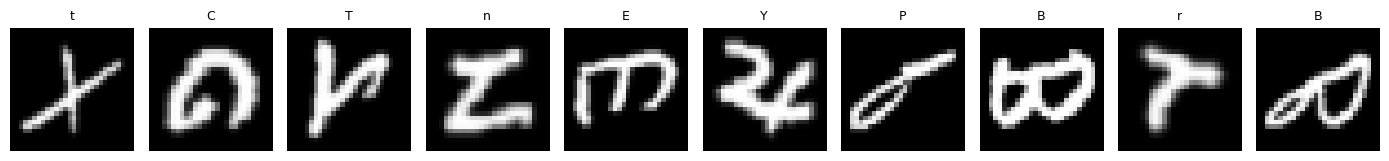

In [6]:
def unnormalize_for_plot(x: torch.Tensor) -> torch.Tensor:
	x = x.detach().cpu().clone()
	x = x * 0.5 + 0.5
	return x.clamp(0, 1)


def show_batch(loader, class_names=None, n: int = 10):
	x, y = next(iter(loader))
	x = unnormalize_for_plot(x[:n])
	y = y[:n]

	plt.figure(figsize=(14, 3))
	for i in range(min(n, len(x))):
		plt.subplot(1, n, i + 1)
		img = x[i]
		if img.shape[0] == 1:
			plt.imshow(img.squeeze(0), cmap="gray")
		else:
			plt.imshow(img.permute(1, 2, 0))
		if class_names is not None and int(y[i]) < len(class_names):
			plt.title(str(class_names[int(y[i])]), fontsize=9)
		else:
			plt.title(str(int(y[i])), fontsize=9)
		plt.axis("off")
	plt.tight_layout()
	plt.show()


show_batch(train_loader, class_names=CLASS_NAMES, n=10)

In [7]:
from pathlib import Path
from copy import deepcopy
from typing import Optional

import math
import torch
import torch.nn as nn


class MLP(nn.Module):
    def __init__(
        self,
        input_shape,
        num_classes: int,
        hidden_sizes=(512, 256, 128),
        activation: str = "relu",
        dropout: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        c, h, w = input_shape
        in_features = c * h * w

        act_name = activation.lower()
        if act_name == "relu":
            act_layer_cls = nn.ReLU
        elif act_name == "tanh":
            act_layer_cls = nn.Tanh
        elif act_name == "gelu":
            act_layer_cls = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers: list[nn.Module] = [nn.Flatten()]
        prev = in_features

        for hidden_dim in hidden_sizes:
            layers.append(nn.Linear(prev, hidden_dim))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(act_layer_cls())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = hidden_dim

        layers.append(nn.Linear(prev, num_classes))  # logits
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class EarlyStopping:
    def __init__(self, patience: int = 4, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score: Optional[float] = None
        self.counter = 0

    def step(self, score: float) -> bool:
        if self.best_score is None:
            self.best_score = score
            self.counter = 0
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience


def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def model_summary_str(model_cfg: dict) -> str:
    hidden = "-".join(map(str, model_cfg["hidden_sizes"]))
    activation = model_cfg["activation"]
    dropout = model_cfg["dropout"]
    batchnorm = model_cfg["use_batchnorm"]
    return f"hidden={hidden}; act={activation}; dropout={dropout}; batchnorm={batchnorm}"

In [8]:
def current_lr(optimizer: torch.optim.Optimizer) -> float:
    return float(optimizer.param_groups[0]["lr"])


def make_optimizer(
    model: nn.Module,
    optimizer_name: str,
    lr: float,
    weight_decay: float = 0.0,
    momentum: float = 0.9,
):
    optimizer_name = optimizer_name.lower()

    if optimizer_name == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    if optimizer_name == "sgd":
        return torch.optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=momentum,
            weight_decay=weight_decay,
        )

    raise ValueError(f"Unknown optimizer: {optimizer_name}")


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            raise RuntimeError("Loss became NaN/Inf during training.")

        loss.backward()
        optimizer.step()

        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_count += batch_size

    return total_loss / total_count, total_correct / total_count


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            raise RuntimeError("Loss became NaN/Inf during evaluation.")

        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_count += batch_size

    return total_loss / total_count, total_correct / total_count


def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int,
    scheduler=None,
    early_stopping: Optional[EarlyStopping] = None,
    verbose: bool = True,
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "lr": [],
    }

    best_state = deepcopy(model.state_dict())
    best_epoch = 0
    best_val_acc = -float("inf")
    best_val_loss_min = float("inf")
    best_val_loss_at_best_epoch = float("inf")

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()

        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        lr_now = current_lr(optimizer)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["lr"].append(lr_now)

        if val_loss < best_val_loss_min:
            best_val_loss_min = val_loss

        is_better = (val_acc > best_val_acc) or (
            math.isclose(val_acc, best_val_acc, rel_tol=0.0, abs_tol=1e-12)
            and val_loss < best_val_loss_at_best_epoch
        )

        if is_better:
            best_val_acc = val_acc
            best_epoch = epoch
            best_val_loss_at_best_epoch = val_loss
            best_state = deepcopy(model.state_dict())

        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        if verbose:
            dt = time.time() - epoch_start
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"lr={lr_now:.2e} | "
                f"train loss={train_loss:.4f}, acc={train_acc:.4f} | "
                f"val loss={val_loss:.4f}, acc={val_acc:.4f} | "
                f"{dt:.1f}s"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(val_acc)
            if should_stop:
                print(
                    f"EarlyStopping triggered at epoch {epoch}. "
                    f"Best epoch: {best_epoch}, best val_acc={best_val_acc:.4f}"
                )
                break

    model.load_state_dict(best_state)

    return {
        "history": history,
        "best_epoch": best_epoch,
        "best_val_acc": float(best_val_acc),
        "best_val_loss": float(best_val_loss_min),
        "best_val_loss_at_best_epoch": float(best_val_loss_at_best_epoch),
    }

In [9]:
from typing import Optional

def plot_history(history: dict, title: str = "", save_path: Optional[Path] = None):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], label="train_loss")
    axes[0].plot(epochs, history["val_loss"], label="val_loss")
    axes[0].set_title(f"{title} — loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="train_acc")
    axes[1].plot(epochs, history["val_acc"], label="val_acc")
    axes[1].set_title(f"{title} — accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].legend()

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=180, bbox_inches="tight")

    plt.show()


def plot_lr_extremes(run_high: dict, run_low: dict, save_path: Optional[Path] = None):
    epochs_high = np.arange(1, len(run_high["history"]["val_loss"]) + 1)
    epochs_low = np.arange(1, len(run_low["history"]["val_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs_high, run_high["history"]["val_loss"], label=f'O1 val_loss (lr={run_high["config"]["lr"]})')
    axes[0].plot(epochs_low, run_low["history"]["val_loss"], label=f'O2 val_loss (lr={run_low["config"]["lr"]})')
    axes[0].set_title("LR extremes — val loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].legend()

    axes[1].plot(epochs_high, run_high["history"]["val_acc"], label=f'O1 val_acc (lr={run_high["config"]["lr"]})')
    axes[1].plot(epochs_low, run_low["history"]["val_acc"], label=f'O2 val_acc (lr={run_low["config"]["lr"]})')
    axes[1].set_title("LR extremes — val accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].legend()

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=180, bbox_inches="tight")

    plt.show()


RUN_REGISTRY = {}
EXPERIMENTS = {}
EXPERIMENT_ORDER = {"E1": 1, "E2": 2, "E3": 3, "E4": 4, "O1": 5, "O2": 6, "O3": 7}


def save_runs_csv():
	if not RUN_REGISTRY:
		return pd.DataFrame()

	df = pd.DataFrame(RUN_REGISTRY.values())

	for col in ["momentum", "weight_decay", "test_accuracy", "test_loss"]:
		if col not in df.columns:
			df[col] = np.nan

	df["__order"] = df["experiment_id"].map(EXPERIMENT_ORDER)
	df = df.sort_values("__order").drop(columns="__order")

	df.to_csv(RUNS_CSV_PATH, index=False)
	return df


def run_experiment(
	experiment_id: str,
	model_cfg: dict,
	optimizer_name: str,
	lr: float,
	weight_decay: float = 0.0,
	momentum: float = 0.0,
	epochs: int = 10,
	use_early_stopping: bool = False,
	early_stopping_patience: int = 4,
	early_stopping_min_delta: float = 0.0,
):
	print("\n" + "=" * 90)
	print(f"Running {experiment_id}")
	print("=" * 90)

	set_seed(SEED)

	model = MLP(
		input_shape=INPUT_SHAPE,
		num_classes=NUM_CLASSES,
		hidden_sizes=tuple(model_cfg["hidden_sizes"]),
		activation=model_cfg["activation"],
		dropout=model_cfg["dropout"],
		use_batchnorm=model_cfg["use_batchnorm"],
	).to(DEVICE)

	optimizer = make_optimizer(
		model,
		optimizer_name=optimizer_name,
		lr=lr,
		weight_decay=weight_decay,
		momentum=momentum,
	)
	criterion = nn.CrossEntropyLoss()

	early_stopper = None
	if use_early_stopping:
		early_stopper = EarlyStopping(
			patience=early_stopping_patience,
			min_delta=early_stopping_min_delta,
		)

	fit_out = fit(
		model=model,
		train_loader=train_loader,
		val_loader=val_loader,
		optimizer=optimizer,
		criterion=criterion,
		device=DEVICE,
		epochs=epochs,
		scheduler=None,
		early_stopping=early_stopper,
		verbose=True,
	)

	result = {
		"experiment_id": experiment_id,
		"model": model,
		"history": fit_out["history"],
		"best_epoch": fit_out["best_epoch"],
		"best_val_acc": fit_out["best_val_acc"],
		"best_val_loss": fit_out["best_val_loss"],
		"best_val_loss_at_best_epoch": fit_out["best_val_loss_at_best_epoch"],
		"config": {
			"dataset": DATASET_NAME,
			"seed": SEED,
			"model_cfg": deepcopy(model_cfg),
			"optimizer": optimizer_name,
			"lr": lr,
			"momentum": momentum,
			"weight_decay": weight_decay,
			"epochs": epochs,
			"use_early_stopping": use_early_stopping,
			"early_stopping_patience": early_stopping_patience if use_early_stopping else None,
			"early_stopping_min_delta": early_stopping_min_delta if use_early_stopping else None,
		},
	}

	row = {
		"experiment_id": experiment_id,
		"dataset": DATASET_NAME,
		"seed": SEED,
		"model_summary": model_summary_str(model_cfg),
		"optimizer": optimizer_name,
		"lr": lr,
		"momentum": momentum if optimizer_name.lower() == "sgd" else 0.0,
		"weight_decay": weight_decay,
		"epochs_trained": len(fit_out["history"]["val_acc"]),
		"best_val_accuracy": fit_out["best_val_acc"],
		"best_val_loss": fit_out["best_val_loss"],
	}

	result["row"] = row
	EXPERIMENTS[experiment_id] = result
	RUN_REGISTRY[experiment_id] = row

	print("trainable params:", count_trainable_params(model))
	print("best_epoch:", result["best_epoch"])
	print("best_val_acc:", f'{result["best_val_acc"]:.4f}')
	print("best_val_loss:", f'{result["best_val_loss"]:.4f}')

	return result


Running E1
Epoch 01/20 | lr=1.00e-03 | train loss=1.3825, acc=0.6034 | val loss=0.8419, acc=0.7453 | 7.5s
Epoch 02/20 | lr=1.00e-03 | train loss=0.7071, acc=0.7749 | val loss=0.6351, acc=0.7975 | 7.9s
Epoch 03/20 | lr=1.00e-03 | train loss=0.5720, acc=0.8115 | val loss=0.5750, acc=0.8106 | 7.6s
Epoch 04/20 | lr=1.00e-03 | train loss=0.5005, acc=0.8314 | val loss=0.5476, acc=0.8218 | 7.9s
Epoch 05/20 | lr=1.00e-03 | train loss=0.4585, acc=0.8421 | val loss=0.4964, acc=0.8341 | 8.1s
Epoch 06/20 | lr=1.00e-03 | train loss=0.4216, acc=0.8515 | val loss=0.4912, acc=0.8348 | 7.8s
Epoch 07/20 | lr=1.00e-03 | train loss=0.3975, acc=0.8585 | val loss=0.4664, acc=0.8395 | 8.0s
Epoch 08/20 | lr=1.00e-03 | train loss=0.3721, acc=0.8652 | val loss=0.4835, acc=0.8382 | 8.3s
Epoch 09/20 | lr=1.00e-03 | train loss=0.3521, acc=0.8702 | val loss=0.4740, acc=0.8423 | 7.8s
Epoch 10/20 | lr=1.00e-03 | train loss=0.3338, acc=0.8755 | val loss=0.4759, acc=0.8440 | 7.8s
Epoch 11/20 | lr=1.00e-03 | train loss

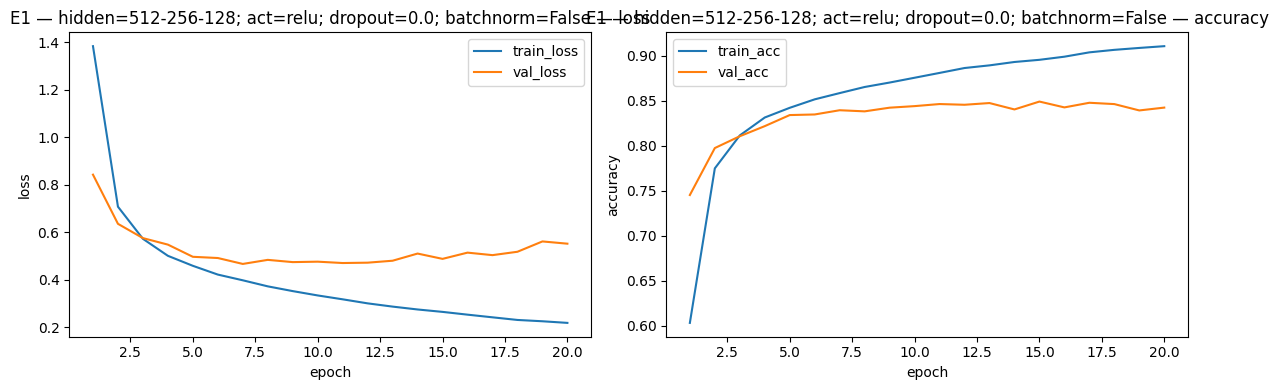


Running E2
Epoch 01/20 | lr=1.00e-03 | train loss=1.7573, acc=0.4916 | val loss=0.8924, acc=0.7262 | 7.9s
Epoch 02/20 | lr=1.00e-03 | train loss=1.0152, acc=0.6849 | val loss=0.7425, acc=0.7669 | 7.6s
Epoch 03/20 | lr=1.00e-03 | train loss=0.8622, acc=0.7295 | val loss=0.6348, acc=0.7954 | 7.9s
Epoch 04/20 | lr=1.00e-03 | train loss=0.7866, acc=0.7495 | val loss=0.5963, acc=0.8080 | 7.9s
Epoch 05/20 | lr=1.00e-03 | train loss=0.7303, acc=0.7653 | val loss=0.5644, acc=0.8163 | 8.1s
Epoch 06/20 | lr=1.00e-03 | train loss=0.7006, acc=0.7728 | val loss=0.5345, acc=0.8258 | 8.0s
Epoch 07/20 | lr=1.00e-03 | train loss=0.6750, acc=0.7811 | val loss=0.5198, acc=0.8259 | 8.3s
Epoch 08/20 | lr=1.00e-03 | train loss=0.6472, acc=0.7864 | val loss=0.5196, acc=0.8269 | 8.1s
Epoch 09/20 | lr=1.00e-03 | train loss=0.6317, acc=0.7912 | val loss=0.4968, acc=0.8336 | 7.8s
Epoch 10/20 | lr=1.00e-03 | train loss=0.6165, acc=0.7953 | val loss=0.4982, acc=0.8338 | 7.8s
Epoch 11/20 | lr=1.00e-03 | train loss

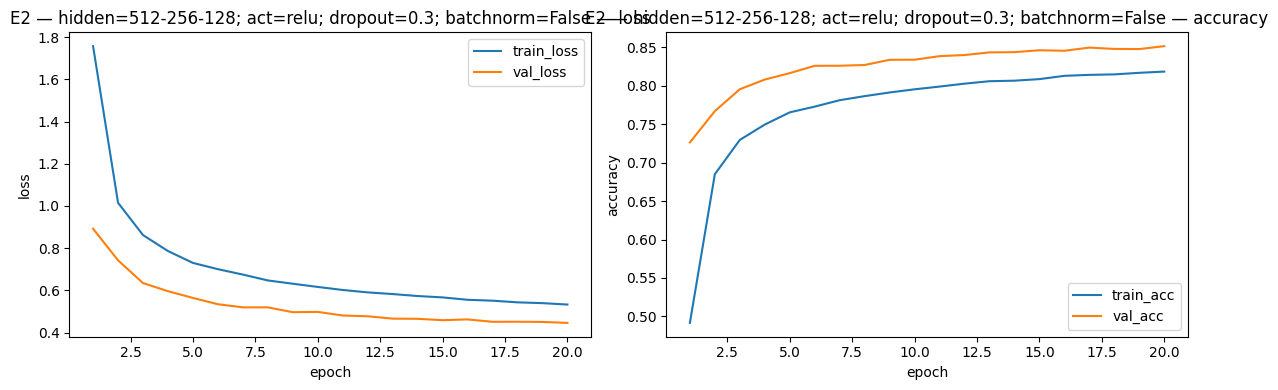


Running E3
Epoch 01/20 | lr=1.00e-03 | train loss=0.9945, acc=0.7412 | val loss=0.5980, acc=0.8055 | 8.0s
Epoch 02/20 | lr=1.00e-03 | train loss=0.4842, acc=0.8376 | val loss=0.4880, acc=0.8364 | 7.8s
Epoch 03/20 | lr=1.00e-03 | train loss=0.4009, acc=0.8597 | val loss=0.4715, acc=0.8408 | 7.9s
Epoch 04/20 | lr=1.00e-03 | train loss=0.3512, acc=0.8734 | val loss=0.4450, acc=0.8499 | 8.2s
Epoch 05/20 | lr=1.00e-03 | train loss=0.3151, acc=0.8836 | val loss=0.4644, acc=0.8451 | 8.3s
Epoch 06/20 | lr=1.00e-03 | train loss=0.2859, acc=0.8926 | val loss=0.4521, acc=0.8484 | 8.1s
Epoch 07/20 | lr=1.00e-03 | train loss=0.2638, acc=0.8988 | val loss=0.4434, acc=0.8520 | 7.9s
Epoch 08/20 | lr=1.00e-03 | train loss=0.2423, acc=0.9052 | val loss=0.4715, acc=0.8458 | 7.7s
Epoch 09/20 | lr=1.00e-03 | train loss=0.2270, acc=0.9101 | val loss=0.4615, acc=0.8495 | 7.7s
Epoch 10/20 | lr=1.00e-03 | train loss=0.2115, acc=0.9150 | val loss=0.4721, acc=0.8482 | 7.5s
Epoch 11/20 | lr=1.00e-03 | train loss

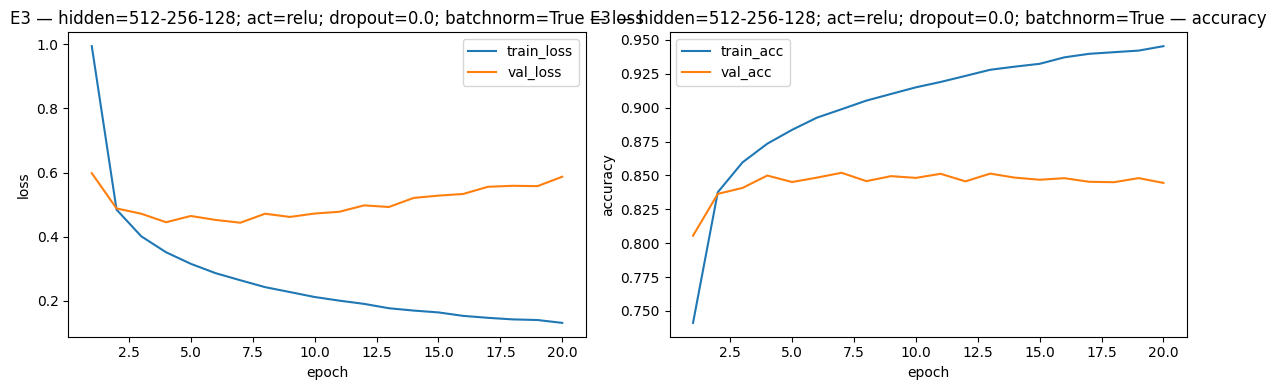

,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss,test_accuracy,test_loss
0,E1,EMNIST_BALANCED,42,hidden=512-256-128; act=relu; dropout=0.0; bat...,Adam,0.001,0.0,0.0,20,0.849069,0.466372,NaN,NaN
1,E2,EMNIST_BALANCED,42,hidden=512-256-128; act=relu; dropout=0.3; bat...,Adam,0.001,0.0,0.0,20,0.851374,0.446122,NaN,NaN
2,E3,EMNIST_BALANCED,42,hidden=512-256-128; act=relu; dropout=0.0; bat...,Adam,0.001,0.0,0.0,20,0.851950,0.443401,NaN,NaN


In [10]:
BASE_MODEL_CFG = {
	"hidden_sizes": [512, 256, 128],
	"activation": "relu",
	"dropout": 0.0,
	"use_batchnorm": False,
}

E1_CFG = deepcopy(BASE_MODEL_CFG)

E2_CFG = deepcopy(BASE_MODEL_CFG)
E2_CFG["dropout"] = 0.30

E3_CFG = deepcopy(BASE_MODEL_CFG)
E3_CFG["use_batchnorm"] = True

PART_A_CONFIGS = {
	"E1": E1_CFG,
	"E2": E2_CFG,
	"E3": E3_CFG,
}

for exp_id, model_cfg in PART_A_CONFIGS.items():
	run = run_experiment(
		experiment_id=exp_id,
		model_cfg=model_cfg,
		optimizer_name="Adam",
		lr=1e-3,
		weight_decay=0.0,
		momentum=0.0,
		epochs=MAX_EPOCHS_A,
		use_early_stopping=False,
	)
	plot_history(run["history"], title=f"{exp_id} — {model_summary_str(model_cfg)}")

df_part_a = save_runs_csv()
df_part_a

In [11]:
candidate_ids = ["E2", "E3"]

selected_from = max(
	candidate_ids,
	key=lambda exp_id: (
		EXPERIMENTS[exp_id]["best_val_acc"],
		-EXPERIMENTS[exp_id]["best_val_loss"],
	),
)

best_candidate_cfg = deepcopy(EXPERIMENTS[selected_from]["config"]["model_cfg"])

print("Лучший кандидат для E4 выбран из:", candidate_ids)
print("selected_from:", selected_from)
print("best_candidate_cfg:", best_candidate_cfg)

Лучший кандидат для E4 выбран из: ['E2', 'E3']
selected_from: E3
best_candidate_cfg: {'hidden_sizes': [512, 256, 128], 'activation': 'relu', 'dropout': 0.0, 'use_batchnorm': True}



Running E4
Epoch 01/40 | lr=1.00e-03 | train loss=0.9945, acc=0.7412 | val loss=0.5980, acc=0.8055 | 8.2s
Epoch 02/40 | lr=1.00e-03 | train loss=0.4842, acc=0.8376 | val loss=0.4880, acc=0.8364 | 7.9s
Epoch 03/40 | lr=1.00e-03 | train loss=0.4009, acc=0.8597 | val loss=0.4715, acc=0.8408 | 7.9s
Epoch 04/40 | lr=1.00e-03 | train loss=0.3512, acc=0.8734 | val loss=0.4450, acc=0.8499 | 8.0s
Epoch 05/40 | lr=1.00e-03 | train loss=0.3151, acc=0.8836 | val loss=0.4644, acc=0.8451 | 7.9s
Epoch 06/40 | lr=1.00e-03 | train loss=0.2859, acc=0.8926 | val loss=0.4521, acc=0.8484 | 8.0s
Epoch 07/40 | lr=1.00e-03 | train loss=0.2638, acc=0.8988 | val loss=0.4434, acc=0.8520 | 7.8s
Epoch 08/40 | lr=1.00e-03 | train loss=0.2423, acc=0.9052 | val loss=0.4715, acc=0.8458 | 8.2s
Epoch 09/40 | lr=1.00e-03 | train loss=0.2270, acc=0.9101 | val loss=0.4615, acc=0.8495 | 7.9s
Epoch 10/40 | lr=1.00e-03 | train loss=0.2115, acc=0.9150 | val loss=0.4721, acc=0.8482 | 7.8s
Epoch 11/40 | lr=1.00e-03 | train loss

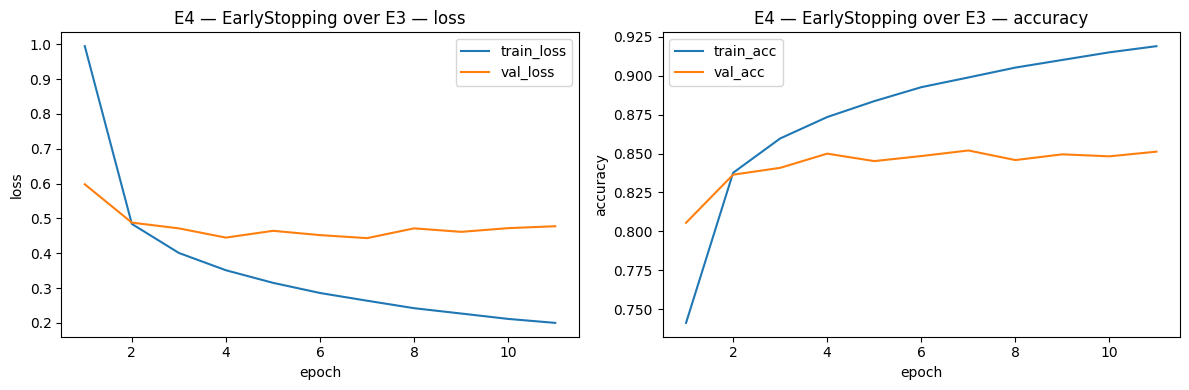

,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss,test_accuracy,test_loss
0,E1,EMNIST_BALANCED,42,hidden=512-256-128; act=relu; dropout=0.0; bat...,Adam,0.001,0.0,0.0,20,0.849069,0.466372,NaN,NaN
1,E2,EMNIST_BALANCED,42,hidden=512-256-128; act=relu; dropout=0.3; bat...,Adam,0.001,0.0,0.0,20,0.851374,0.446122,NaN,NaN
2,E3,EMNIST_BALANCED,42,hidden=512-256-128; act=relu; dropout=0.0; bat...,Adam,0.001,0.0,0.0,20,0.851950,0.443401,NaN,NaN
3,E4,EMNIST_BALANCED,42,hidden=512-256-128; act=relu; dropout=0.0; bat...,Adam,0.001,0.0,0.0,11,0.851950,0.443401,NaN,NaN


In [12]:
e4_run = run_experiment(
	experiment_id="E4",
	model_cfg=best_candidate_cfg,
	optimizer_name="Adam",
	lr=1e-3,
	weight_decay=0.0,
	momentum=0.0,
	epochs=MAX_EPOCHS_E4,
	use_early_stopping=True,
	early_stopping_patience=EARLY_STOPPING_PATIENCE,
	early_stopping_min_delta=EARLY_STOPPING_MIN_DELTA,
)

plot_history(
	e4_run["history"],
	title=f'E4 — EarlyStopping over {selected_from}',
	save_path=CURVES_BEST_PATH,
)

df_after_e4 = save_runs_csv()
df_after_e4

In [13]:
criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(EXPERIMENTS["E4"]["model"], test_loader, criterion, DEVICE)

RUN_REGISTRY["E4"]["test_loss"] = float(test_loss)
RUN_REGISTRY["E4"]["test_accuracy"] = float(test_acc)

best_config = {
	"dataset": DATASET_NAME,
	"seed": SEED,
	"val_ratio": VAL_RATIO,
	"batch_size": BATCH_SIZE,
	"num_workers": NUM_WORKERS,
	"device": str(DEVICE),
	"transform": TRANSFORM_DESC,
	"input_shape": list(INPUT_SHAPE),
	"num_classes": NUM_CLASSES,
	"selected_from_for_e4": selected_from,
	"model": deepcopy(EXPERIMENTS["E4"]["config"]["model_cfg"]),
	"training": {
		"optimizer": EXPERIMENTS["E4"]["config"]["optimizer"],
		"lr": EXPERIMENTS["E4"]["config"]["lr"],
		"weight_decay": EXPERIMENTS["E4"]["config"]["weight_decay"],
		"epochs_max": EXPERIMENTS["E4"]["config"]["epochs"],
		"early_stopping_patience": EXPERIMENTS["E4"]["config"]["early_stopping_patience"],
		"early_stopping_min_delta": EXPERIMENTS["E4"]["config"]["early_stopping_min_delta"],
	},
	"best_epoch": EXPERIMENTS["E4"]["best_epoch"],
	"best_val_accuracy": EXPERIMENTS["E4"]["best_val_acc"],
	"best_val_loss": EXPERIMENTS["E4"]["best_val_loss"],
	"test_loss": float(test_loss),
	"test_accuracy": float(test_acc),
}

torch.save(EXPERIMENTS["E4"]["model"].state_dict(), BEST_MODEL_PATH)
with open(BEST_CONFIG_PATH, "w", encoding="utf-8") as f:
	json.dump(best_config, f, ensure_ascii=False, indent=2)

final_df = save_runs_csv()

print("E4 test_loss:", f"{test_loss:.4f}")
print("E4 test_acc :", f"{test_acc:.4f}")
print("Saved model :", BEST_MODEL_PATH)
print("Saved config:", BEST_CONFIG_PATH)
print("Saved figure:", CURVES_BEST_PATH)

final_df

E4 test_loss: 0.4600
E4 test_acc : 0.8511
Saved model : artifacts/best_model.pt
Saved config: artifacts/best_config.json
Saved figure: artifacts/figures/curves_best.png


,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss,test_loss,test_accuracy
0,E1,EMNIST_BALANCED,42,hidden=512-256-128; act=relu; dropout=0.0; bat...,Adam,0.001,0.0,0.0,20,0.849069,0.466372,NaN,NaN
1,E2,EMNIST_BALANCED,42,hidden=512-256-128; act=relu; dropout=0.3; bat...,Adam,0.001,0.0,0.0,20,0.851374,0.446122,NaN,NaN
2,E3,EMNIST_BALANCED,42,hidden=512-256-128; act=relu; dropout=0.0; bat...,Adam,0.001,0.0,0.0,20,0.851950,0.443401,NaN,NaN
3,E4,EMNIST_BALANCED,42,hidden=512-256-128; act=relu; dropout=0.0; bat...,Adam,0.001,0.0,0.0,11,0.851950,0.443401,0.459993,0.851117



Running O1
Epoch 01/6 | lr=1.00e-01 | train loss=1.0164, acc=0.6894 | val loss=0.7578, acc=0.7609 | 7.7s
Epoch 02/6 | lr=1.00e-01 | train loss=0.6717, acc=0.7793 | val loss=0.7197, acc=0.7722 | 7.6s
Epoch 03/6 | lr=1.00e-01 | train loss=0.5763, acc=0.8063 | val loss=0.5784, acc=0.8042 | 7.7s
Epoch 04/6 | lr=1.00e-01 | train loss=0.5274, acc=0.8201 | val loss=0.5733, acc=0.8198 | 7.8s
Epoch 05/6 | lr=1.00e-01 | train loss=0.4933, acc=0.8297 | val loss=0.5926, acc=0.8074 | 8.0s
Epoch 06/6 | lr=1.00e-01 | train loss=0.4758, acc=0.8337 | val loss=0.5722, acc=0.8121 | 7.9s
trainable params: 573999
best_epoch: 4
best_val_acc: 0.8198
best_val_loss: 0.5722

Running O2
Epoch 01/6 | lr=1.00e-05 | train loss=3.4852, acc=0.1765 | val loss=3.1364, acc=0.3445 | 7.6s
Epoch 02/6 | lr=1.00e-05 | train loss=2.9329, acc=0.4358 | val loss=2.7546, acc=0.5008 | 7.8s
Epoch 03/6 | lr=1.00e-05 | train loss=2.6177, acc=0.5378 | val loss=2.4926, acc=0.5650 | 7.8s
Epoch 04/6 | lr=1.00e-05 | train loss=2.3841, ac

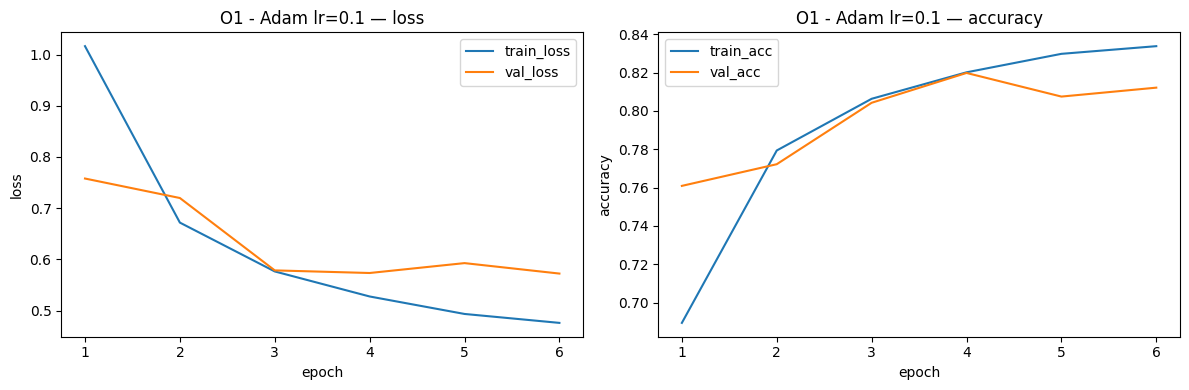

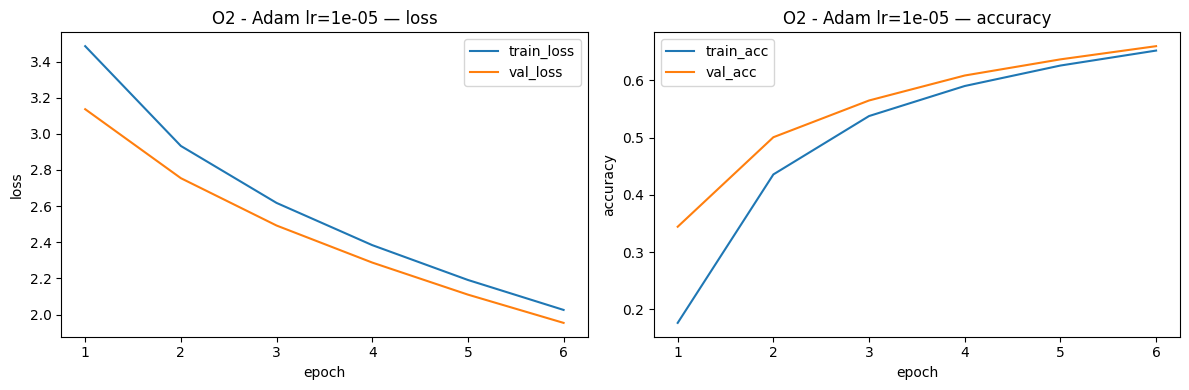

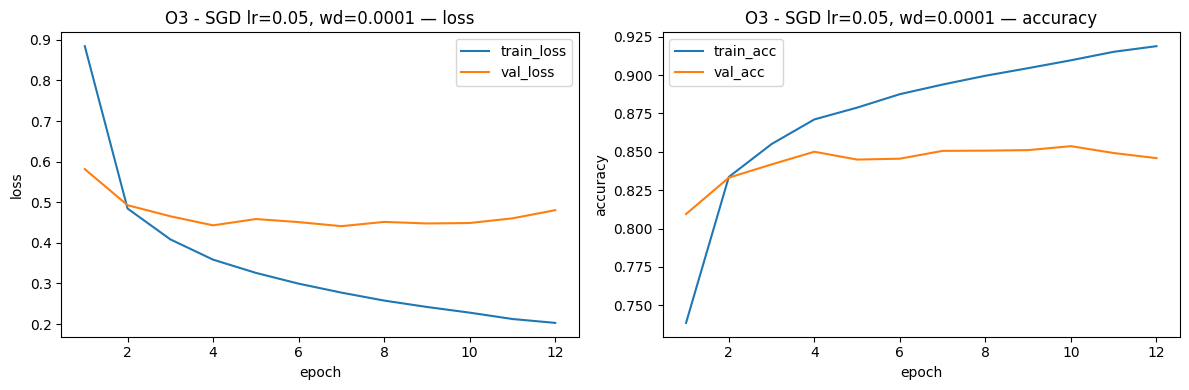

In [14]:
FIXED_MODEL_CFG = deepcopy(EXPERIMENTS["E4"]["config"]["model_cfg"])

O3_LR = 5e-2

o1_run = run_experiment(
	experiment_id="O1",
	model_cfg=FIXED_MODEL_CFG,
	optimizer_name="Adam",
	lr=1e-1,
	weight_decay=0.0,
	momentum=0.0,
	epochs=EPOCHS_LR_EXTREMES,
	use_early_stopping=False,
)

o2_run = run_experiment(
	experiment_id="O2",
	model_cfg=FIXED_MODEL_CFG,
	optimizer_name="Adam",
	lr=1e-5,
	weight_decay=0.0,
	momentum=0.0,
	epochs=EPOCHS_LR_EXTREMES,
	use_early_stopping=False,
)

o3_run = run_experiment(
	experiment_id="O3",
	model_cfg=FIXED_MODEL_CFG,
	optimizer_name="SGD",
	lr=O3_LR,
	weight_decay=1e-4,
	momentum=0.9,
	epochs=EPOCHS_O3,
	use_early_stopping=False,
)

plot_history(o1_run["history"], title=f'O1 - Adam lr={o1_run["config"]["lr"]}')
plot_history(o2_run["history"], title=f'O2 - Adam lr={o2_run["config"]["lr"]}')
plot_history(o3_run["history"], title=f'O3 - SGD lr={o3_run["config"]["lr"]}, wd={o3_run["config"]["weight_decay"]}')

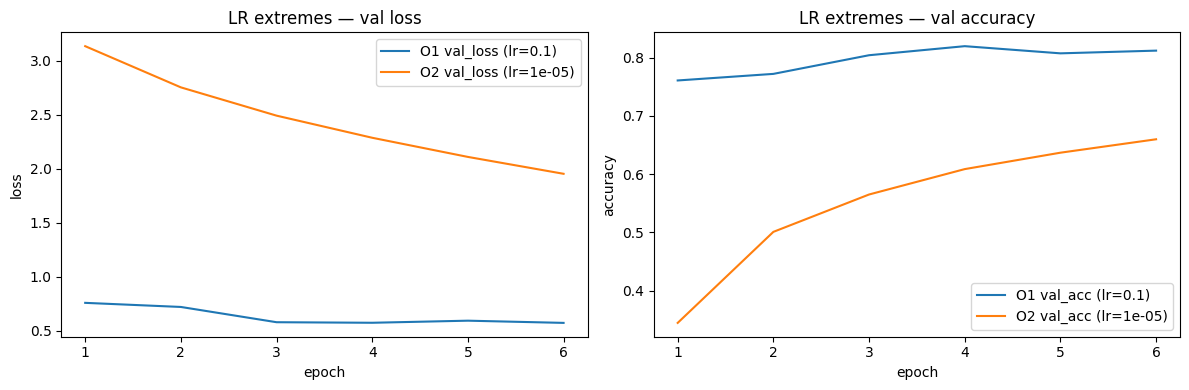

Saved LR figure: artifacts/figures/curves_lr_extremes.png


,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss,test_loss,test_accuracy
0,E1,EMNIST_BALANCED,42,hidden=512-256-128; act=relu; dropout=0.0; bat...,Adam,0.00100,0.0,0.0000,20,0.849069,0.466372,NaN,NaN
1,E2,EMNIST_BALANCED,42,hidden=512-256-128; act=relu; dropout=0.3; bat...,Adam,0.00100,0.0,0.0000,20,0.851374,0.446122,NaN,NaN
2,E3,EMNIST_BALANCED,42,hidden=512-256-128; act=relu; dropout=0.0; bat...,Adam,0.00100,0.0,0.0000,20,0.851950,0.443401,NaN,NaN
3,E4,EMNIST_BALANCED,42,hidden=512-256-128; act=relu; dropout=0.0; bat...,Adam,0.00100,0.0,0.0000,11,0.851950,0.443401,0.459993,0.851117
4,O1,EMNIST_BALANCED,42,hidden=512-256-128; act=relu; dropout=0.0; bat...,Adam,0.10000,0.0,0.0000,6,0.819770,0.572157,NaN,NaN
5,O2,EMNIST_BALANCED,42,hidden=512-256-128; act=relu; dropout=0.0; bat...,Adam,0.00001,0.0,0.0000,6,0.659840,1.953700,NaN,NaN
6,O3,EMNIST_BALANCED,42,hidden=512-256-128; act=relu; dropout=0.0; bat...,SGD,0.05000,0.9,0.0001,12,0.853679,0.441087,NaN,NaN


In [15]:
plot_lr_extremes(
	run_high=EXPERIMENTS["O1"],
	run_low=EXPERIMENTS["O2"],
	save_path=CURVES_LR_EXTREMES_PATH,
)

final_df = save_runs_csv()

print("Saved LR figure:", CURVES_LR_EXTREMES_PATH)
final_df

In [16]:
e1 = EXPERIMENTS["E1"]
e2 = EXPERIMENTS["E2"]
e3 = EXPERIMENTS["E3"]
e4 = EXPERIMENTS["E4"]
o1 = EXPERIMENTS["O1"]
o2 = EXPERIMENTS["O2"]
o3 = EXPERIMENTS["O3"]

print("=== Summary for report.md ===")
print(f"Dataset: {DATASET_NAME}")
print(f"Transform: {TRANSFORM_DESC}")
print(f"Best candidate before E4: {selected_from}")
print(f"E4 best_epoch: {e4['best_epoch']}")
print(f"E4 best_val_accuracy: {e4['best_val_acc']:.4f}")
print(f"E4 best_val_loss: {e4['best_val_loss']:.4f}")
print(f"E4 test_accuracy: {test_acc:.4f}")
print()
print(f"O1 (too high LR={o1['config']['lr']}): best_val_acc={o1['best_val_acc']:.4f}, final_val_loss={o1['history']['val_loss'][-1]:.4f}")
print(f"O2 (too low  LR={o2['config']['lr']}): best_val_acc={o2['best_val_acc']:.4f}, final_val_loss={o2['history']['val_loss'][-1]:.4f}")
print(f"O3 (SGD, lr={o3['config']['lr']}, wd={o3['config']['weight_decay']}): best_val_acc={o3['best_val_acc']:.4f}")

=== Summary for report.md ===
Dataset: EMNIST_BALANCED
Transform: ToTensor() + Normalize((0.5,), (0.5,))
Best candidate before E4: E3
E4 best_epoch: 7
E4 best_val_accuracy: 0.8520
E4 best_val_loss: 0.4434
E4 test_accuracy: 0.8511

O1 (too high LR=0.1): best_val_acc=0.8198, final_val_loss=0.5722
O2 (too low  LR=1e-05): best_val_acc=0.6598, final_val_loss=1.9537
O3 (SGD, lr=0.05, wd=0.0001): best_val_acc=0.8537


In [17]:
report_md = f"""# HW08-09 – PyTorch MLP: регуляризация и оптимизация обучения

## 1. Кратко: что сделано

- Выбран датасет: **{DATASET_NAME}**.
- В части A сравнивались E1-E4: base MLP, Dropout, BatchNorm, EarlyStopping.
- В части B сравнивались O1-O3: слишком большой LR, слишком маленький LR, SGD+momentum + weight decay.

## 2. Среда и воспроизводимость

- Python: {platform.python_version()}
- torch / torchvision: {torch.__version__} / {getattr(torchvision, "__version__", "unknown")}
- Устройство (CPU/GPU): {DEVICE}
- Seed: {SEED}
- Как запустить: открыть `HW08-09.ipynb` и выполнить Run All.

## 3. Данные

- Датасет: {DATASET_NAME}
- Разделение: train/val/test = стандартный torchvision train/test + val из train ({int((1 - VAL_RATIO) * 100)}/{int(VAL_RATIO * 100)})
- Трансформации (transform): {TRANSFORM_DESC}
- Комментарий: {DATASET_NOTE}

## 4. Базовая модель и обучение

- Модель MLP (кратко): hidden_sizes={EXPERIMENTS["E4"]["config"]["model_cfg"]["hidden_sizes"]}, activation={EXPERIMENTS["E4"]["config"]["model_cfg"]["activation"]}
- Loss: CrossEntropyLoss
- Базовый Optimizer (для части A): Adam (lr=1e-3)
- Batch size: {BATCH_SIZE}
- Epochs (макс): {MAX_EPOCHS_A} для E1-E3, {MAX_EPOCHS_E4} для E4
- EarlyStopping: patience={EARLY_STOPPING_PATIENCE}, metric=val_accuracy

## 5. Часть A (S08): регуляризация (E1-E4)

- E1 (base): {model_summary_str(E1_CFG)}
- E2 (Dropout): {model_summary_str(E2_CFG)}
- E3 (BatchNorm): {model_summary_str(E3_CFG)}
- E4 (EarlyStopping): выбран лучший из (E2/E3) = {selected_from}, затем обучен с EarlyStopping

## 6. Часть B (S09): LR, оптимизаторы, weight decay (O1-O3)

- O1: LR слишком большой (Adam, lr={o1["config"]["lr"]})
- O2: LR слишком маленький (Adam, lr={o2["config"]["lr"]})
- O3: SGD+momentum (momentum={o3["config"]["momentum"]}) + weight_decay={o3["config"]["weight_decay"]} (lr={o3["config"]["lr"]})

## 7. Результаты

Ссылки на файлы в репозитории:

- Таблица результатов: `./artifacts/runs.csv`
- Лучшая модель: `./artifacts/best_model.pt`
- Конфиг лучшей модели: `./artifacts/best_config.json`
- Кривые лучшего прогона: `./artifacts/figures/curves_best.png`
- Кривые “плохих LR”: `./artifacts/figures/curves_lr_extremes.png`

Короткая сводка:

- Лучший эксперимент части A: E4
- Лучшая val_accuracy: {e4["best_val_acc"]:.4f}
- Итоговая test_accuracy (для лучшей модели): {test_acc:.4f}
- Что видно на O1 (слишком большой LR): обучение нестабильно / метрики ведут себя хуже
- Что видно на O2 (слишком маленький LR): обучение идёт слишком медленно
- Как повёл себя O3 (SGD+momentum + weight decay) относительно Adam: см. кривые и `runs.csv`

## 8. Анализ

Здесь допишите 8-15 предложений по итогам графиков и метрик.

## 9. Итоговый вывод

Здесь допишите 3-7 предложений с финальным выводом.

## 10. Приложение (опционально)

Если делались дополнительные сравнения, добавьте их сюда.
"""

report_path = HW_DIR / "report.md"
report_path.write_text(report_md, encoding="utf-8")

print("Draft report written to:", report_path)
print(report_path.read_text(encoding="utf-8")[:1500])

Draft report written to: report.md
# HW08-09 – PyTorch MLP: регуляризация и оптимизация обучения

## 1. Кратко: что сделано

- Выбран датасет: **EMNIST_BALANCED**.
- В части A сравнивались E1-E4: base MLP, Dropout, BatchNorm, EarlyStopping.
- В части B сравнивались O1-O3: слишком большой LR, слишком маленький LR, SGD+momentum + weight decay.

## 2. Среда и воспроизводимость

- Python: 3.13.5
- torch / torchvision: 2.10.0+cu128 / 0.25.0+cu128
- Устройство (CPU/GPU): cuda
- Seed: 42
- Как запустить: открыть `HW08-09.ipynb` и выполнить Run All.

## 3. Данные

- Датасет: EMNIST_BALANCED
- Разделение: train/val/test = стандартный torchvision train/test + val из train (80/20)
- Трансформации (transform): ToTensor() + Normalize((0.5,), (0.5,))
- Комментарий: EMNIST Balanced: 47 классов, grayscale, 28x28.

## 4. Базовая модель и обучение

- Модель MLP (кратко): hidden_sizes=[512, 256, 128], activation=relu
- Loss: CrossEntropyLoss
- Базовый Optimizer (для части A): Adam (lr=1e-3)
- Batch size: